# Argo Data Access

In this notebook we show how to invoke a simple argo data access service hosted by [Euro-Argo ERIC](https://euro-argo.eu).
This has been complemented in April 2025 with the interfacing to the Nerc Vocabulary Server for a seamless interrogation from the [EXV](https://vocab.nerc.ac.uk/collection/EXV/current/) vocabulary, through a sparql query (see section V).
2025/05/13 edit: Further fine-tuning are required to make sure all parameters are correctly matched-up, and Argopy well linked.

## I - Setting up the environment

Argo access services do not use any credentials or authentification. Thus, nothing more is necessary.

## II - Installing dependencies

To use this data access service, you need to install [ArgoPy python library](https://github.com/euroargodev/argopy?tab=readme-ov-file):

In what follows, the exclamation mark `!` is used to send command directly to the Operating System. The following command installs the required dependencies detailed in the `requirements.txt` file present in the project root folder. Put the cursor in the following cell and press the `Run` button: (To DO: ask Guillaume for the file for argopy)

In [1]:
! pip install -r requirements_argo.txt

Right now you should have all the required dependencies *installed* on your interpreter, but they are not yet *visible*, i.e., your code does not know where to find them. To be able to use them, you need to *import* them as follows:

In [2]:
import argopy
import numpy as np
import matplotlib as mpl
import time
from matplotlib import pyplot as plt
from argopy import DataFetcher
from SPARQLWrapper import SPARQLWrapper, JSON
print("Check Library versions")
print("argopy -> ",argopy.__version__)
print("numpy -> ",np.__version__)
print("matplotlib -> ",mpl.__version__)

Check Library versions
argopy ->  1.2.0
numpy ->  1.26.4
matplotlib ->  3.10.1


If the above cell raised an error, it means that something went wrong while installing the dependencies.

## III - Argopy library Usage

Argopy python library is a wrap-up library on top of several Argo data access services. The Argopy complete documentation is available online at the following link:
[here](https://argopy.readthedocs.io/en/latest/).\
There is also a nice "cheat sheet" summing up the main features and usage [here](https://argopy.readthedocs.io/en/latest/cheatsheet.html) \
The complete citation of this service is: \
`Maze, G., & Balem, K. (2020). argopy: A Python library for Argo ocean data analysis. Journal of Open Source Software, 5(53). //doi.org/10.21105/joss.02425`

The main basic functions that will be used in this example notebook are briefly described herebelow.

### III.1 - data source service selection
By default the service used to fetch Argo data is the [Ifremer erdapp server](http://www.ifremer.fr/erddap) : 
+ `argopy.set_options(src='erddap')` \
Other sources, including local copy or referenced copies of Argo datasets, can be fetched. Details are available [here](https://argopy.readthedocs.io/en/latest/user-guide/fetching-argo-data/data_sources.html)

### III.2 - argo dataset type depending on the ExV
Argo dataset inner architecture is differentiated whether they relate to a physical parameter (which are temperature and salinity) or a biogeochemical parameter (oxygen, nitrate, pH, light - irradiance -, particles - backscattering-, chlorophyll-A). How to handle this concretely will be presented hereafter.
+ `argopy.set_options(ds='bgc')`
+ `argopy.set_options(ds='phy')`

### III.3 - argo parameter selection
Argopy allows to select parameters to load within the dataFetcher method. By default, all available parameters are loaded. Details are available [here](https://argopy.readthedocs.io/en/latest/user-guide/fetching-argo-data/data_set.html#the-params-argument)
+ `argopy.DataFetcher(params='all')`
+ `argopy.DataFetcher(params='PSAL')`
+ `argopy.DataFetcher(params=['DOXY','PSAL'])`

Argopy also allows to query the Argo NVS tables. The [Argo parameter table](https://vocab.nerc.ac.uk/search_nvs/R03/) is of particular interest as it will be mapped with the [ExV](https://vocab.nerc.ac.uk/search_nvs/EXV/) table.
+ `from argopy import ArgoNVSReferenceTables`
+ `ArgoNVSReferenceTables().tbl('R03')`

### III.4 - spatio-temporal selection
The Argopy library allows to select data by using its DataFetcher method, which can be called in several manners :
 + defining a region: `ArgoSet = DataFetcher().region([-85 ,-45 ,10. ,20. ,0 ,10,'2023-01', '2025-06' ])`
 + selecting by Argo floats ID : `ArgoSet = DataFetcher().float([6902746, 6902747, 6902757])`
 + selecting specific profiles of an Argo float: `ArgoSet = DataFetcher().profile(6902746,34)`

The *interface* of the three methods are as follows:
+ *region* parameter consists in a list defining the area of interest as a rectangular space-time domain. The boundaries must be ordered as follows in the list:
   + western boundary in degreesEast within the `[-180 180]` domain;
   + eastern boundary in degreesEast within the `[-180 180]` domain;
   + southern boundary in degreesNorth within the `[-90 90]` domain;
   + northern boundary in degreesNorth within the `[-90 90]` domain;
   + upper layer in dbar within the `[0 6000]` domain : 0 means at the sea surface, 6000 means at the greatest depth possibly reached by an Argo float;
   + lower layer in dbar within the `[0 6000]` domain;
   + start time `[optionnal]` : the oldest date time in ISO-8601 format "YYYY-MM" or "YYYY-MM-DD" ;
   + end time `[optionnal]`: the most recent date time in ISO-8601 format. When not indicated, the whole dataset time domain is requested ;


+ *float* parameter is a list of floats wmo IDs `[integer]` (for more experience users)
+ *profile* parameters consists in a float wmo ID and either a single profile as in the above example or an array containing 2 elements: the first and last profile to fetch. For instance, `ArgoSet = DataFetcher().profile(6902746,[1,34])` will fetch all data from cycle 1 to 34 (again for more experienced users).

### III.5 - User modes: level of details in the outputs, quality and level of processing considered
The argo files are very rich, containing a lot of information, which can be difficult to manipulate, especially for people not implied in the data management process. To simplify and provide data ready for studies and analysis, the argoPy embeds a nice *user mode* selection possibility, which is detailed [here](https://argopy.readthedocs.io/en/latest/user-guide/fetching-argo-data/user_mode.html).
In the ENVRI-Hub context, recommended modes are either "standard" (default configuration) or "research" modes. Briefly, standard mode contains the best possible good data (both real-time data and expert-reviewed data), while research mode only contains good data that were expert-reviewed. 
+ `argopy.set_options(mode='standard')`
+ `argopy.set_options(mode='research')`
  
### III.6 - output formating
Data can be output in several format such as dataframes or datasets:
+ `DataFetcher().profile(6902746, 34).to_dataframe()`
+ `DataFetcher().profile(6902746, 34).to_xarray()`


Let's make some practical examples.

## IV - Examples

In [3]:
src='erddap' # erddap or gdac

### IV.1 get surface temperature data around the Ligurian region ( ;-) )

In [4]:
%%time

lon_west,lon_east=7,15
lat_south,lat_north=42,45
#lon_west,lon_east=6,12
#lat_south,lat_north=41,47
#lon_west,lon_east=0,20
#lat_south,lat_north=30,50
depth_min,depth_max=0,2000

date_min,date_max='2022-05-01','2022-08-01'

argopy.set_options(src=src,ds='phy',mode='standard')
f=DataFetcher().region([lon_west,lon_east,lat_south,lat_north,depth_min,depth_max,date_min,date_max])
print(f)
ds=f.to_xarray()
#ds=f.to_dataframe()
#ds=f.data
print(ds)

<datafetcher.erddap>
⭐ Name: Ifremer erddap Argo data fetcher for a space/time region
🗺  Domain: [x=7.00/15.00; y=42.00/45.00; z=0.0/2000.0; t=2022-05-01/2022-08-01]
🔗 API: https://erddap.ifremer.fr/erddap
🏊 User mode: standard
🟡+🔵 Dataset: phy
🌥  Performances: cache=False, parallel=False
<xarray.Dataset> Size: 112kB
Dimensions:          (N_POINTS: 1274)
Coordinates:
    LATITUDE         (N_POINTS) float64 10kB 43.67 43.67 43.67 ... 43.74 43.74
    LONGITUDE        (N_POINTS) float64 10kB 14.22 14.22 14.22 ... 14.19 14.19
    TIME             (N_POINTS) datetime64[ns] 10kB 2022-05-02T06:13:20 ... 2...
  * N_POINTS         (N_POINTS) int32 5kB 0 1 2 3 4 ... 1269 1270 1271 1272 1273
Data variables: (12/15)
    CYCLE_NUMBER     (N_POINTS) int32 5kB 10 10 10 10 10 10 ... 28 28 28 28 28
    DATA_MODE        (N_POINTS) <U1 5kB 'R' 'R' 'R' 'R' 'R' ... 'R' 'R' 'R' 'R'
    DIRECTION        (N_POINTS) <U1 5kB 'A' 'A' 'A' 'A' 'A' ... 'A' 'A' 'A' 'A'
    PLATFORM_NUMBER  (N_POINTS) int32 5kB 69038

#### IV.1.b - Retrieve only surface points (closest to surface at each float ascent)

In [5]:
dsargo=ds.argo.point2profile()
dsargo_surf=dsargo.isel(N_LEVELS=0)

#### IV.1.c - Plot spatially

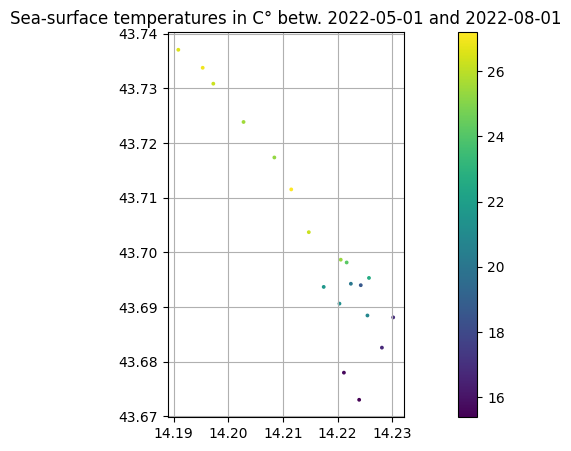

In [6]:
plt.figure(figsize=(14,5))
plt.axes().set_aspect('equal')
plt.title('Sea-surface temperatures in C° betw. ' + date_min + ' and ' + date_max)
plt.grid()
plt.scatter(dsargo_surf['LONGITUDE'], dsargo_surf['LATITUDE'], c=dsargo_surf['TEMP'], marker="o", cmap="viridis",s=3)
plt.colorbar()
plt.show()

#### IV.1.d - Plot temporally

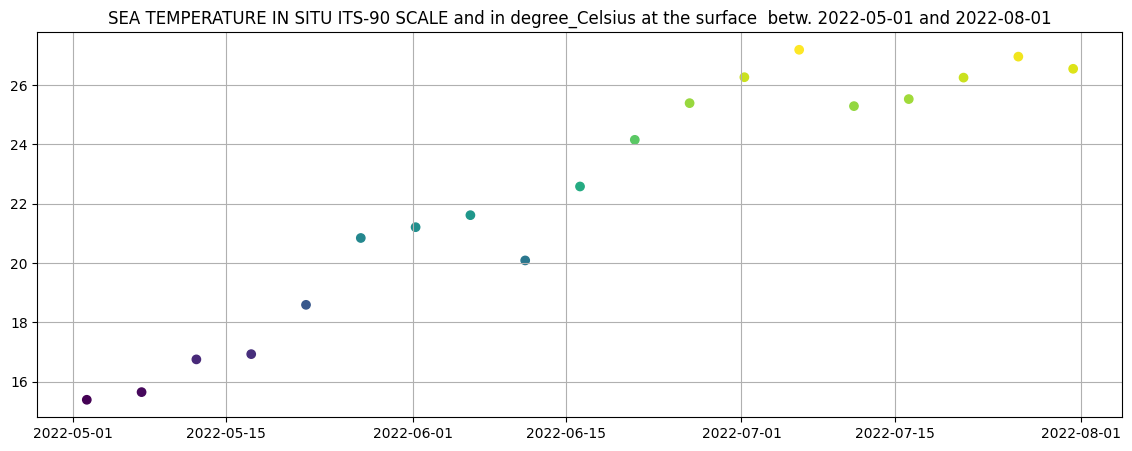

In [7]:
plt.figure(figsize = (14, 5))
plt.title(ds['TEMP'].attrs['long_name'] + ' and in ' + ds['TEMP'].attrs['units'] + ' at the surface ' + ' betw. ' + date_min + ' and ' + date_max)
plt.scatter(dsargo_surf['TIME'],dsargo_surf['TEMP'],c=dsargo_surf['TEMP'], marker="o", cmap="viridis")
plt.grid()
plt.show()

#### IV.1.e - Plot Vertically

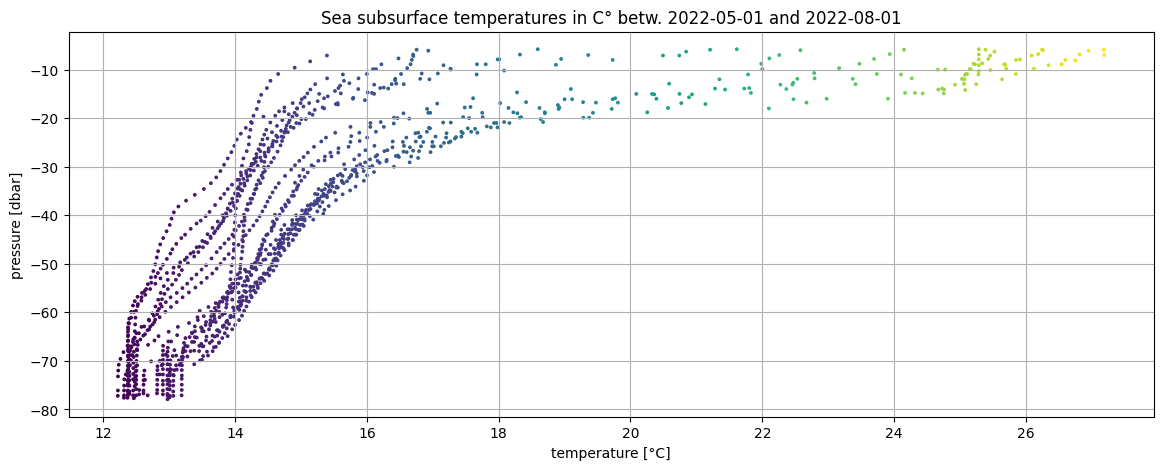

In [8]:
plt.figure(figsize = (14, 5))
plt.title('Sea subsurface temperatures in C° betw. ' + date_min + ' and ' + date_max)
plt.scatter(ds['TEMP'],-ds['PRES'],c=ds['TEMP'], marker="o", cmap="viridis",s=3)
plt.ylabel('pressure [dbar]') 
plt.xlabel('temperature [°C]')
plt.grid()
plt.show()

#### IV.1.f - Plot source floats trajectories

(<Figure size 900x540 with 1 Axes>,
 <Axes: xlabel='longitude', ylabel='latitude'>)

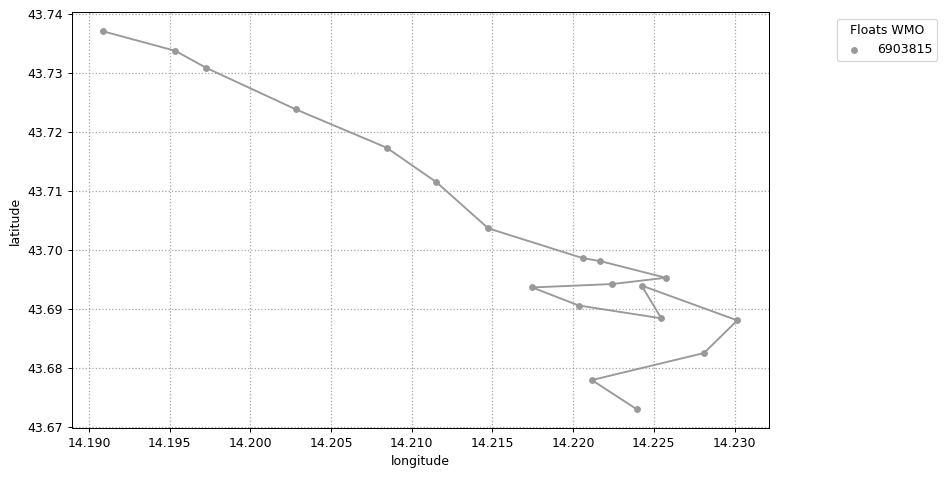

In [9]:
f.plot('trajectory')

### IV.2 combines oxygen and surface temperature data around the Ligurian region ( ;-) )

Here we are looking for argo data with both dissolved oxygen and temperature simultaneously measured. No data were accessible in the previously selected area. It has been slightly changed from the previous example.

In [10]:
%%time
#lon_west,lon_east=7,15
#lat_south,lat_north=42,45
#lon_west,lon_east=5,13
#lat_south,lat_north=40,48
lon_west,lon_east=0,20
lat_south,lat_north=30,50
depth_min,depth_max=0,2000

date_min,date_max='2022-05-01','2022-08-01'

argopy.set_options(src=src,ds='bgc',mode='standard')
f=DataFetcher(params="DOXY").region([lon_west,lon_east,lat_south,lat_north,depth_min,depth_max,date_min,date_max])
print(f)
ds=f.to_xarray()
#ds=f.to_dataframe()
#ds=f.data
print(ds)

<datafetcher.erddap>
⭐ Name: Ifremer erddap Argo BGC data fetcher for a space/time region
🗺  Domain: [x=0.00/20.00; y=30.00/50.00; z=0.0/2000.0; t=2022-05-01/2022-08-01]
🔗 API: https://erddap.ifremer.fr/erddap
📗 Parameters: ['DOXY', 'PRES', 'TEMP', 'PSAL']
📕 BGC 'must be measured' parameters: []
🏊 User mode: standard
🟢 Dataset: bgc-s
🌥  Performances: cache=False, parallel=False
<xarray.Dataset> Size: 4MB
Dimensions:          (N_POINTS: 33478)
Coordinates:
    LATITUDE         (N_POINTS) float64 268kB 40.45 40.45 40.45 ... 42.81 42.81
    LONGITUDE        (N_POINTS) float64 268kB 2.227 2.227 2.227 ... 15.69 15.69
    TIME             (N_POINTS) datetime64[ns] 268kB 2022-05-01T09:05:20 ... ...
  * N_POINTS         (N_POINTS) int32 134kB 0 1 2 3 ... 33474 33475 33476 33477
Data variables: (12/21)
    CYCLE_NUMBER     (N_POINTS) int32 134kB 161 161 161 161 ... 246 246 246 246
    DIRECTION        (N_POINTS) <U1 134kB 'A' 'A' 'A' 'A' ... 'A' 'A' 'A' 'A'
    DOXY             (N_POINTS) float

#### IV.2.b - Retrieve only surface points (closest to surface at each float ascent)

In [11]:
dsargo=ds.argo.point2profile()
dsargo_surf=dsargo.isel(N_LEVELS=0)

#### IV.2.c - Plot spatially

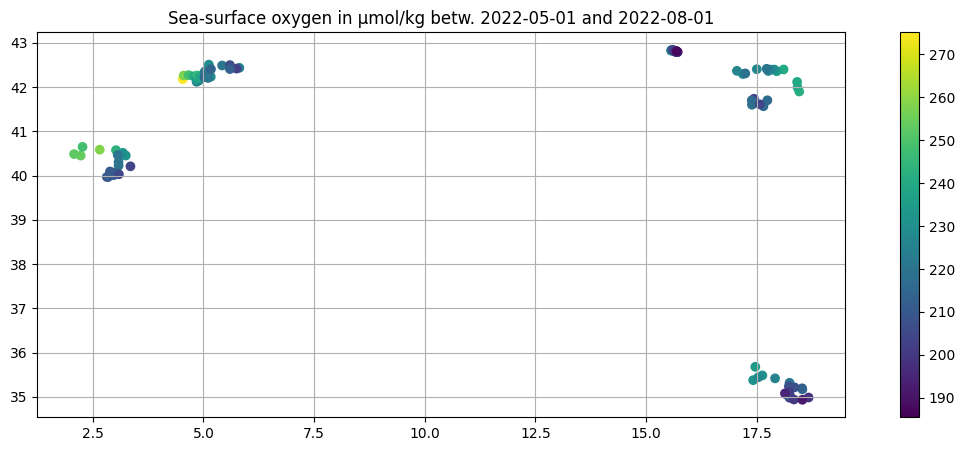

In [12]:
plt.figure(figsize=(14,5))
plt.axes().set_aspect('equal')
plt.title('Sea-surface oxygen in µmol/kg betw. ' + date_min + ' and ' + date_max)
plt.grid()
plt.scatter(dsargo_surf['LONGITUDE'], dsargo_surf['LATITUDE'], c=dsargo_surf['DOXY'], marker="o", cmap="viridis")
plt.colorbar()
plt.show()

#### IV.2.d - Plot temporally

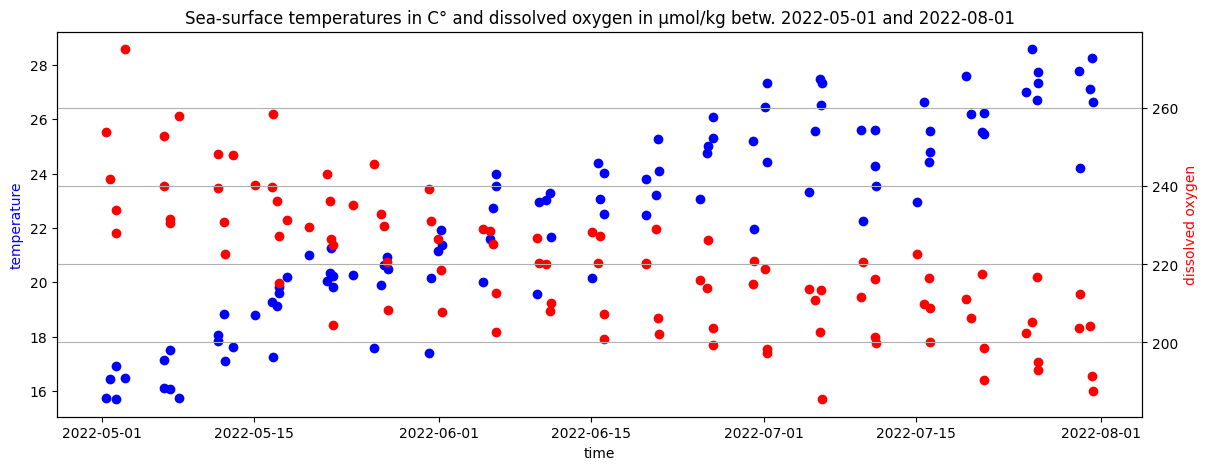

In [13]:
fig, ax1 = plt.subplots(figsize = (14, 5))
plt.title('Sea-surface temperatures in C° and dissolved oxygen in µmol/kg betw. ' + date_min + ' and ' + date_max)
ax2 = ax1.twinx()
ax1.scatter(dsargo_surf['TIME'],dsargo_surf['TEMP'],c='b', marker="o")
ax2.scatter(dsargo_surf['TIME'],dsargo_surf['DOXY'],c='r', marker="o")
ax1.set_xlabel('time')
ax1.set_ylabel('temperature', color='b')
ax2.set_ylabel('dissolved oxygen', color='r')
plt.grid()
plt.show()

#### IV.2.e - Plot Vertically

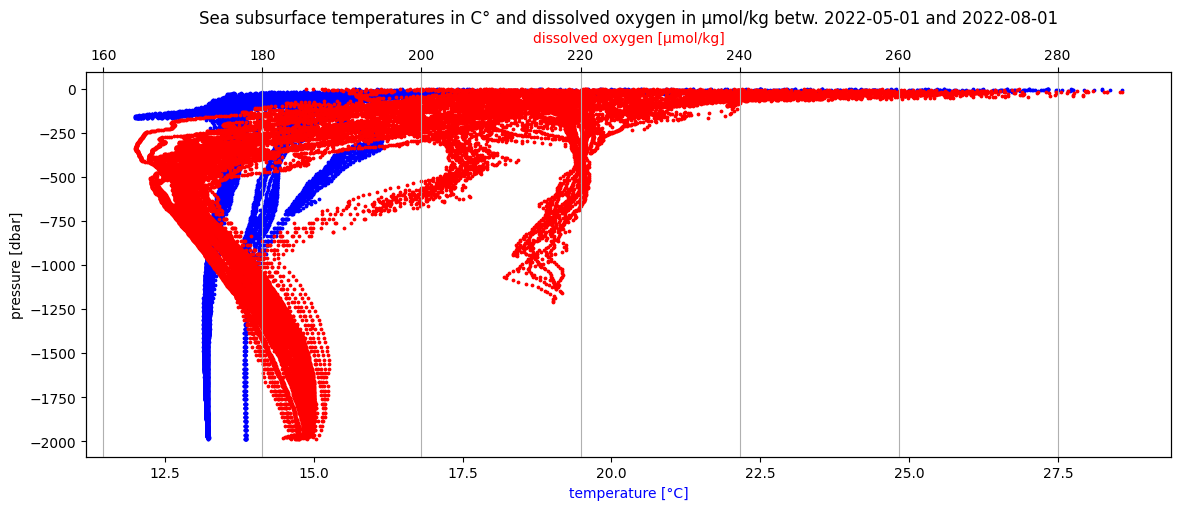

In [14]:
fig, ax1 = plt.subplots(figsize = (14, 5))
plt.title('Sea subsurface temperatures in C° and dissolved oxygen in µmol/kg betw. ' + date_min + ' and ' + date_max)
ax2 = ax1.twiny()
ax1.scatter(ds['TEMP'],-ds['PRES'],c='b', marker="o",s=3)
ax2.scatter(ds['DOXY'],-ds['PRES'],c='r', marker="o",s=3)
ax1.set_ylabel('pressure [dbar]')
ax1.set_xlabel('temperature [°C]', color='b')
ax2.set_xlabel('dissolved oxygen [µmol/kg]', color='r')
plt.grid()
plt.show()

#### V - Access from an EXV parameter - ADDITION FROM EHN HACKATHON - APRIL 2025

In [15]:
def EXV_iadopt(exv_code):
    # SPARQL endpoint
    endpoint_url = "https://vocab.nerc.ac.uk/sparql/"

    # Construct full identifier
    exv_identifier = f"SDN:EXV::{exv_code}"

    # Create the query with the user input
    query = f"""
    PREFIX owl: <http://www.w3.org/2002/07/owl#>
    PREFIX dce: <http://purl.org/dc/elements/1.1/>
    PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
    PREFIX iadopt: <https://w3id.org/iadopt/ont#> 
    PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
    
    SELECT DISTINCT ?r03 ?prefLabel ?notation
    
    WHERE {{
      ?exv a skos:Concept .
      ?exv dce:identifier "{exv_identifier}" .
      
      OPTIONAL {{?exv iadopt:hasApplicableMatrix ?matrix .}}
      ?exv iadopt:hasApplicableObjectOfInterest ?ooi .
      ?exv iadopt:hasApplicableProperty ?property .
      
      <http://vocab.nerc.ac.uk/collection/P01/current/> skos:member ?p01 .
    
      OPTIONAL {{ ?p01 iadopt:hasMatrix ?matrix . }}
      ?p01 iadopt:hasObjectOfInterest ?ooi .
      ?p01 iadopt:hasProperty ?property .
    
      <http://vocab.nerc.ac.uk/collection/R03/current/> skos:member ?r03 .
      
      ?r03 owl:sameAs ?p01
      
      OPTIONAL {{ ?r03 skos:prefLabel ?prefLabel . }}
      OPTIONAL {{ ?r03 skos:notation ?notation . }}
    
    }}



    
    """

    # Set up the SPARQL request
    sparql = SPARQLWrapper(endpoint_url)
    sparql.setQuery(query)
    sparql.setReturnFormat(JSON)

    # Run the query and parse results
    results = sparql.query().convert()

    codes = []

    # Show results
    for result in results["results"]["bindings"]:
        uri = result.get("r03", {}).get("value", "")
        codes.append(uri.rstrip("/").split("/")[-1])

    
    return codes



In [16]:
for exv in ["EXV017","EXV018","EXV019","EXV020","EXV028","EXV033","EXV029","EXV030"]:
        matching_r03s = EXV_iadopt(exv)
        print(exv,":",matching_r03s)
    
    #Expected outputs:\n",
    # see rationale https://docs.google.com/document/d/1utc2zoJbGc6qwhrO1H5k7t8j-xj6Zq5Xr5lixD3LPsI/edit?tab=t.0 at Euro-Argo section\n",
    #EXV017 : ['TEMP'] - sea surface temperature\n",
    #EXV018 : ['TEMP'] - underneath sea level\n",
    #EXV019 : ['PSAL'] - sea surface salinity\n",
    #EXV020 : ['PSAL'] - underneath sea level\n",
    #EXV028 : ['DOXY', 'MLPL_DOXY']\n",
    #EXV033 : ['CHLA','BBP700','DOWN_IRRADIANCE380','DOWN_IRRADIANCE412','DOWN_IRRADIANCE490','DOWNWELLING_PAR'] # NVS is missing iop relationships\n",
    #                                                                                                              for BBP and irradiance\n",
    #EXV029 : ['MOLAR_NITRATE', 'NITRATE']\n",
    #EXV030 : ['PH_IN_SITU_TOTAL'] # https://vocab.nerc.ac.uk/collection/EXV/current/EXV030/?_profile=iop&_mediatype=text/html is missing \n",
    #                                hasApplicableProperty S06:S0600277\n",
    #                                hashasApplicableObjectOfInterest S21:S21S027\n"

EXV017 : ['TEMP']
EXV018 : ['TEMP']
EXV019 : ['PSAL']
EXV020 : ['PSAL']
EXV028 : ['DOXY', 'MLPL_DOXY']
EXV033 : ['CHLA']
EXV029 : ['MOLAR_NITRATE', 'NITRATE']
EXV030 : []


In [17]:
# INPUT PARAMETERIZATION
allds={}

lon_west,lon_east=0,20
lat_south,lat_north=30,50
depth_min,depth_max=0,2000
date_min,date_max='2022-05-01','2022-08-01'
src='erddap' # 'erddap' or 'gdac'

for exv in ["EXV018","EXV020","EXV028","EXV033","EXV029"]: #,"EXV030"]:
#for exv in ["EXV018"]: 
    t_start=time.time()

    # STEP 1: get the Argo internal parameter names
    matching_r03s = EXV_iadopt(exv)
    print("\nExtracting Argo data for ")
    print(matching_r03s)
    
    # STEP 2: perform a match between possible parameters accepted by the argopy service (TO BE FINE-TUNED MORE PRECISELY)
    #The 'params' argument must have values in [BBP700,CDOM,CHLA,DOWNWELLING_PAR,DOWN_IRRADIANCE380,DOWN_IRRADIANCE412,
    # DOWN_IRRADIANCE490,DOXY,NITRATE,PRES,PSAL,TEMP]
    #accepted_params=["BBP700","CDOM","CHLA","DOWNWELLING_PAR","DOWN_IRRADIANCE380","DOWN_IRRADIANCE412",
    #                 "DOWN_IRRADIANCE490","DOXY","NITRATE","PRES","PSAL","TEMP"]
    accepted_params=np.concatenate((argopy.utils.list_bgc_s_variables(),argopy.utils.list_core_parameters()))

    matching_r03s=list(set(matching_r03s).intersection(set(accepted_params)))
    print("Accepted by Argopy:")
    print(matching_r03s)
    #matching_r03s=matching_r03s[0]
    
    # STEP 3: look for which dataset (s) depending on requested parameters (TO BE FINE-TUNED MORE PRECISELY)
    
    if exv in ["EXV017","EXV018","EXV019","EXV020"]:
        dstype='phy'
    else:
        if exv in ["EXV028","EXV029","EXV030","EXV033"]:
            dstype='bgc'
        else:
            print ("ERROR: this EXV is not supported by Argo data")
    
    
    # STEP 4: call the service
    argopy.set_options(src=src,ds=dstype,mode='standard')
    f=DataFetcher(params=matching_r03s).region([lon_west,lon_east,lat_south,lat_north,depth_min,depth_max,date_min,date_max])
    print(f)
    
    # STEP 5: prepare the output
    ds=f.to_xarray()
    allds[exv]=ds

    t_end=time.time()
    print("Execution_time= {:.1f} s".format(t_end - t_start))
#ds=f.to_dataframe()
#ds=f.data
#print(ds)
print(allds)


Extracting Argo data for 
['TEMP']
Accepted by Argopy:
['TEMP']
<datafetcher.erddap>
⭐ Name: Ifremer erddap Argo data fetcher for a space/time region
🗺  Domain: [x=0.00/20.00; y=30.00/50.00; z=0.0/2000.0; t=2022-05-01/2022-08-01]
🔗 API: https://erddap.ifremer.fr/erddap
🏊 User mode: standard
🟡+🔵 Dataset: phy
🌥  Performances: cache=False, parallel=False
Execution_time= 31.0 s

Extracting Argo data for 
['PSAL']
Accepted by Argopy:
['PSAL']
<datafetcher.erddap>
⭐ Name: Ifremer erddap Argo data fetcher for a space/time region
🗺  Domain: [x=0.00/20.00; y=30.00/50.00; z=0.0/2000.0; t=2022-05-01/2022-08-01]
🔗 API: https://erddap.ifremer.fr/erddap
🏊 User mode: standard
🟡+🔵 Dataset: phy
🌥  Performances: cache=False, parallel=False
Execution_time= 24.8 s

Extracting Argo data for 
['DOXY', 'MLPL_DOXY']
Accepted by Argopy:
['DOXY']
<datafetcher.erddap>
⭐ Name: Ifremer erddap Argo BGC data fetcher for a space/time region
🗺  Domain: [x=0.00/20.00; y=30.00/50.00; z=0.0/2000.0; t=2022-05-01/2022-08-

Execution_time= 20.1 s
{'EXV018': <xarray.Dataset> Size: 38MB
Dimensions:          (N_POINTS: 429823)
Coordinates:
    LATITUDE         (N_POINTS) float64 3MB 38.88 38.88 38.88 ... 38.23 38.23
    LONGITUDE        (N_POINTS) float64 3MB 5.573 5.573 5.573 ... 2.914 2.914
    TIME             (N_POINTS) datetime64[ns] 3MB 2022-05-01T02:10:30 ... 20...
  * N_POINTS         (N_POINTS) int32 2MB 0 1 2 3 ... 429820 429821 429822
Data variables: (12/15)
    CYCLE_NUMBER     (N_POINTS) int32 2MB 209 209 209 209 ... 230 230 230 230
    DATA_MODE        (N_POINTS) <U1 2MB 'D' 'D' 'D' 'D' 'D' ... 'D' 'D' 'D' 'D'
    DIRECTION        (N_POINTS) <U1 2MB 'A' 'A' 'A' 'A' 'A' ... 'A' 'A' 'A' 'A'
    PLATFORM_NUMBER  (N_POINTS) int32 2MB 6902876 6902876 ... 6903016 6903016
    POSITION_QC      (N_POINTS) int32 2MB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    PRES             (N_POINTS) float32 2MB 2.9 3.8 4.8 ... 719.5 721.4 723.4
    ...               ...
    PSAL_ERROR       (N_POINTS) float32 2MB 0.01 